Training a classifier for hand-written digits from the MNIST data-set.
Attempted two different algorithms:

    -> Socratic Gradient Descent, which led to 89.8% arruracy
    -> KNN, led to the surprising arruracy of 97.5% 


    #Warning!



The following KNN model searches hyperparameters via gridsearch,
along with several cross validations the code took 240 min to compute

    on a - AMD Ryzen 5 3600XT (12) @ 3.800GHz

In [1]:
import os
import pandas as pd
import sklearn
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.metrics import precision_recall_curve, accuracy_score
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.base import clone

assert sklearn.__version__ >= "0.20"
plt.style.use('dark_background')

from sklearn.datasets import fetch_openml


In [2]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

(70000, 784)
(70000,)


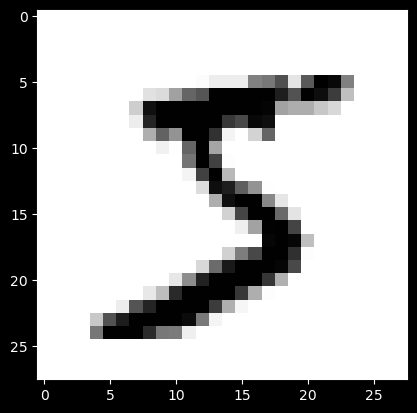

In [3]:
X,y = mnist["data"], mnist["target"]
y = y.astype(np.uint8)
print(X.shape)
print(y.shape)

first_digit = X[0]
img_first = first_digit.reshape(28,28)

plt.imshow(img_first, cmap = "binary")
plt.show()

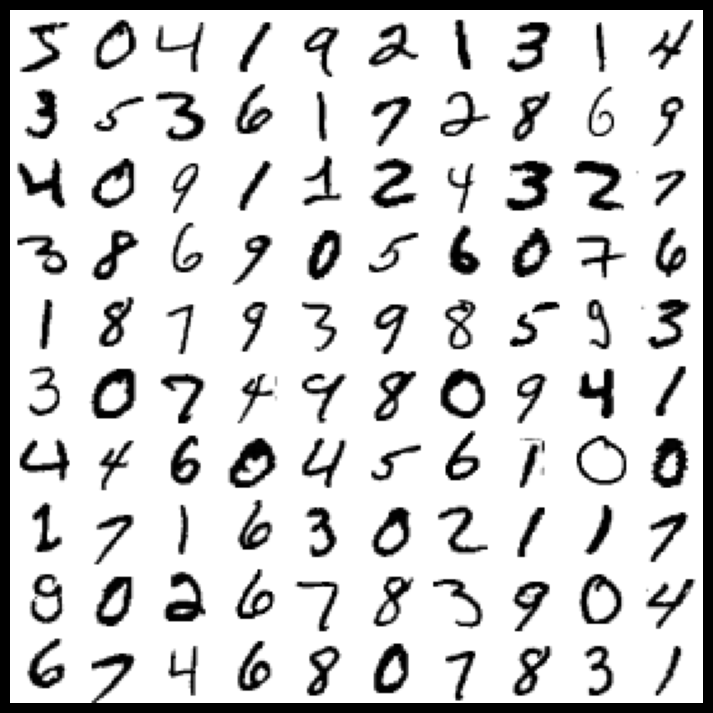

In [4]:
def plot_digits(instances, images_per_row=10, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)
    n_rows = (len(instances) - 1) // images_per_row + 1
    n_empty = n_rows * images_per_row - len(instances)
    padded_instances = np.concatenate([instances, np.zeros((n_empty, size * size))], axis=0)
    image_grid = padded_instances.reshape((n_rows, images_per_row, size, size))
    big_image = image_grid.transpose(0, 2, 1, 3).reshape(n_rows * size,
                                                         images_per_row * size)

    plt.imshow(big_image, cmap = mpl.cm.binary, **options)
    plt.axis("off")

plt.figure(figsize=(9,9))
example_images = X[:100]
plot_digits(example_images, images_per_row=10)
plt.show()

In [5]:
def plot_roc_curve(fpr, tpr, label =None):
    plt.plot(fpr,tpr,linewidth=2, label=label)
    plt.plot([0,1],[0,1], 'k--')

def plot_precision_recall_vs_threshhold(precision, recalls, thresholds):
    plt.plot(thresholds,precision[:-1],"b--", label = "Precision")
    plt.plot(thresholds, recalls[:-1], "g--", label = "Recall")
    [...]


from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.base import clone



def plot_roc_curve(fpr, tpr, label =None):
    plt.plot(fpr,tpr,linewidth=2, label=label)
    plt.plot([0,1],[0,1], 'k--')


def plot_precision_recall_vs_threshhold(precision, recalls, thresholds):
    plt.plot(thresholds,precision[:-1],"b--", label = "Precision")
    plt.plot(thresholds, recalls[:-1], "g--", label = "Recall")
    [...]


In [6]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train,y_train)

scaler= StandardScaler()
X_train_Scaled = scaler.fit_transform(X_train.astype(np.float64))
cross_val_score(sgd_clf, X_train_Scaled, y_train, cv=3, scoring="accuracy")


array([0.8983, 0.891 , 0.9018])

In [7]:
y_train_pred = cross_val_predict(sgd_clf, X_train_Scaled, y_train, cv=3)
conf_matrix = confusion_matrix(y_train,y_train_pred)


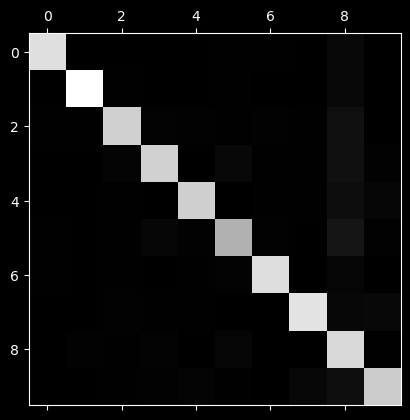

In [8]:
plt.matshow(conf_matrix, cmap = plt.cm.gray)

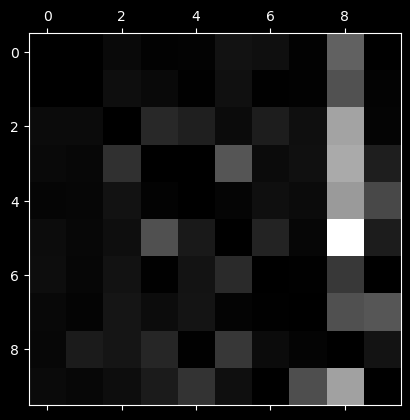

In [9]:
row_sums = conf_matrix.sum(axis=1,keepdims=True)
norm_conf_mx = conf_matrix/row_sums
np.fill_diagonal(norm_conf_mx,0)

plt.matshow(norm_conf_mx, cmap=plt.cm.grey)
plt.show()

In [10]:
from scipy.ndimage.interpolation import shift

def shift_image(image, dx, dy):
    image = image.reshape((28, 28))
    shifted_image = shift(image, [dy, dx], cval=0, mode="constant")
    return shifted_image.reshape([-1])


/tmp/ipykernel_8863/2785426931.py:1: DeprecationWarning: Please import `shift` from the `scipy.ndimage` namespace; the `scipy.ndimage.interpolation` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.interpolation import shift


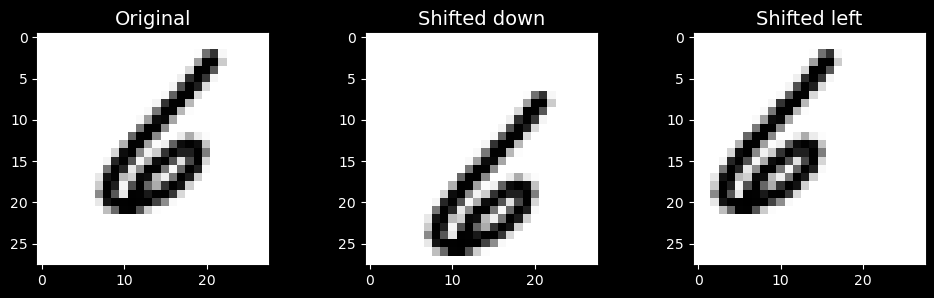

In [11]:
image = X_train[999]
img_shifted_down = shift_image(image, 0, 5)
img_shifted_left = shift_image(image, -5, 0)

# Research how much to shift
plt.figure(figsize=(12,3))
plt.subplot(131)
plt.title("Original", fontsize=14)
plt.imshow(image.reshape(28, 28), interpolation="nearest", cmap="Greys")
plt.subplot(132)
plt.title("Shifted down", fontsize=14)
plt.imshow(img_shifted_down.reshape(28, 28), interpolation="nearest", cmap="Greys")
plt.subplot(133)
plt.title("Shifted left", fontsize=14)
plt.imshow(img_shifted_left.reshape(28, 28), interpolation="nearest", cmap="Greys")
plt.show()

def plot_digit(data):
    image = data.reshape(28, 28)
    plt.imshow(image, cmap = mpl.cm.binary,
               interpolation="nearest")
    plt.axis("off")

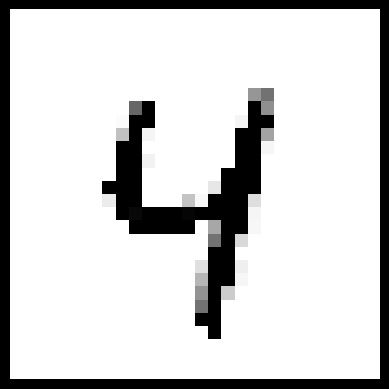

In [12]:
from sklearn.neighbors import KNeighborsClassifier
noise = np.random.randint(0,100,(len(X_train), 784))
X_train_mod = X_train + noise
noise = np.random.randint(0,100,(len(X_test), 784))
X_test_mod = X_test + noise

y_train_mod = X_train

knn_clf = KNeighborsClassifier()
some_digit = 42

knn_clf.fit(X_train_mod, y_train_mod)
clear_digit = knn_clf.predict([X_test_mod[some_digit]])
plot_digits(clear_digit)
y_test_mod = X_test
# should I Use it actually ?

In [13]:
X_train_augmented = [image for image in X_train]
Y_train_augmented = [label for label in y_train]

for dx, dy in ((1, 0), (-1, 0), (0, 1), (0, -1)):
    for image, label in zip(X_train, y_train):
        X_train_augmented.append(shift_image(image, dx, dy))
        Y_train_augmented.append(label)

X_train_augmented = np.array(X_train_augmented)
y_train_augmented = np.array(Y_train_augmented)

In [14]:
shuffle_idx = np.random.permutation(len(X_train_augmented))
X_train_augmented = X_train_augmented[shuffle_idx]
y_train_augmented = y_train_augmented[shuffle_idx]

In [15]:
from sklearn.model_selection import GridSearchCV
param_grid = [{'weights':["uniform","distance"], "n_neighbors":[3,4,5]}]

grid_search = GridSearchCV(knn_clf, param_grid, cv = 5, verbose=3)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV 1/5] END ....n_neighbors=3, weights=uniform;, score=0.972 total time= 5.6min
[CV 2/5] END ....n_neighbors=3, weights=uniform;, score=0.971 total time= 5.6min
[CV 3/5] END ....n_neighbors=3, weights=uniform;, score=0.969 total time= 5.5min
[CV 4/5] END ....n_neighbors=3, weights=uniform;, score=0.969 total time= 5.4min
[CV 5/5] END ....n_neighbors=3, weights=uniform;, score=0.970 total time= 5.5min
[CV 1/5] END ...n_neighbors=3, weights=distance;, score=0.972 total time= 5.4min
[CV 2/5] END ...n_neighbors=3, weights=distance;, score=0.972 total time= 5.4min
[CV 3/5] END ...n_neighbors=3, weights=distance;, score=0.970 total time= 5.5min
[CV 4/5] END ...n_neighbors=3, weights=distance;, score=0.970 total time= 5.6min
[CV 5/5] END ...n_neighbors=3, weights=distance;, score=0.971 total time= 5.5min
[CV 1/5] END ....n_neighbors=4, weights=uniform;, score=0.969 total time= 5.5min
[CV 2/5] END ....n_neighbors=4, weights=uniform;,

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid=[{'n_neighbors': [3, 4, 5],
                          'weights': ['uniform', 'distance']}],
             verbose=3)

In [19]:
file = open("Normal_HyperParams.txt", "w")
file.write(str(grid_search.best_params_.values))
file.close()
#Optimal Hyperparameters
#grid_search.best_params_ = {'n_neighbors': 4, 'weights': 'distance'}
grid_search.best_params_

{'n_neighbors': 4, 'weights': 'distance'}

In [17]:

knn_clf = KNeighborsClassifier(**grid_search.best_params_)
knn_clf.fit(X_train_augmented, y_train_augmented)
y_pred= knn_clf.predict(X_test)

accuracy_score(y_test, y_pred)

0.9763